=== CARGANDO Y PREPARANDO DATOS ===
Materias disponibles para análisis: ['GRAMMAR', 'SPEAKING', 'LISTENING', 'WRITING', 'READING']
Evaluaciones completas: 4191

Dataset final para análisis de combinaciones: (4191, 5)

1. ANÁLISIS DE CORRELACIÓN ENTRE MATERIAS

Matriz de correlación (Pearson):
MATERIA    GRAMMAR  SPEAKING  LISTENING  WRITING  READING
MATERIA                                                  
GRAMMAR      1.000     0.341      0.469    0.330    0.389
SPEAKING     0.341     1.000      0.205    0.461    0.270
LISTENING    0.469     0.205      1.000    0.184    0.265
WRITING      0.330     0.461      0.184    1.000    0.223
READING      0.389     0.270      0.265    0.223    1.000

Correlaciones significativas (p < 0.05):
  GRAMMAR - SPEAKING: r = 0.341, p = 0.0000
  GRAMMAR - LISTENING: r = 0.469, p = 0.0000
  GRAMMAR - WRITING: r = 0.330, p = 0.0000
  GRAMMAR - READING: r = 0.389, p = 0.0000
  SPEAKING - LISTENING: r = 0.205, p = 0.0000
  SPEAKING - WRITING: r = 0.461, p = 

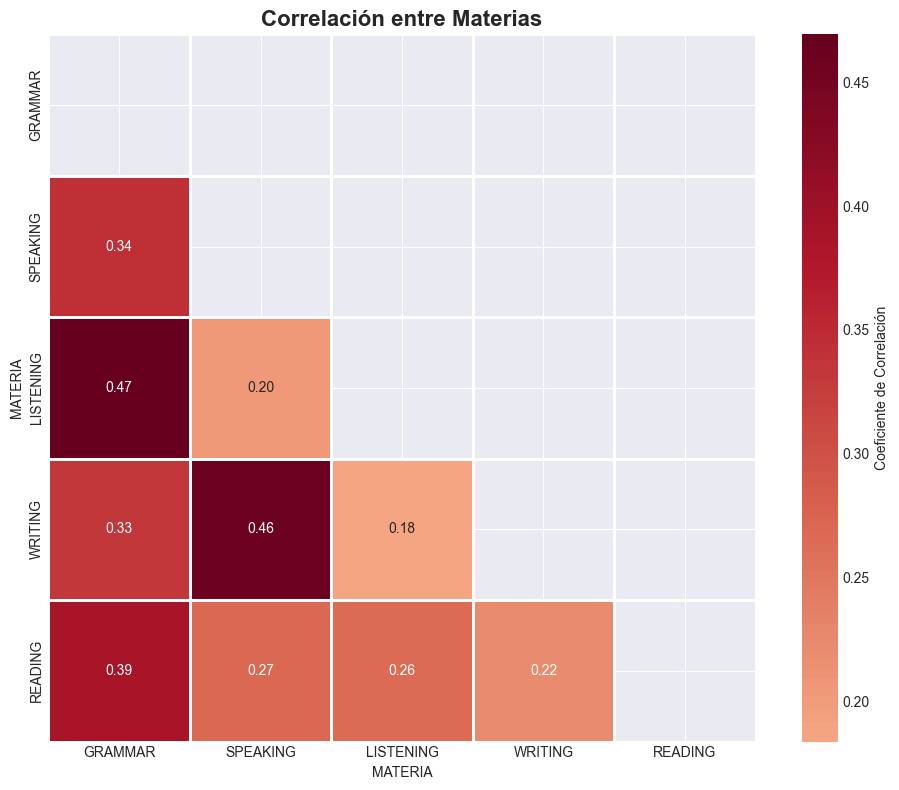


2. ANÁLISIS DE GRUPOS Y COMBINACIONES

a) Análisis de Clúster Jerárquico de Materias:


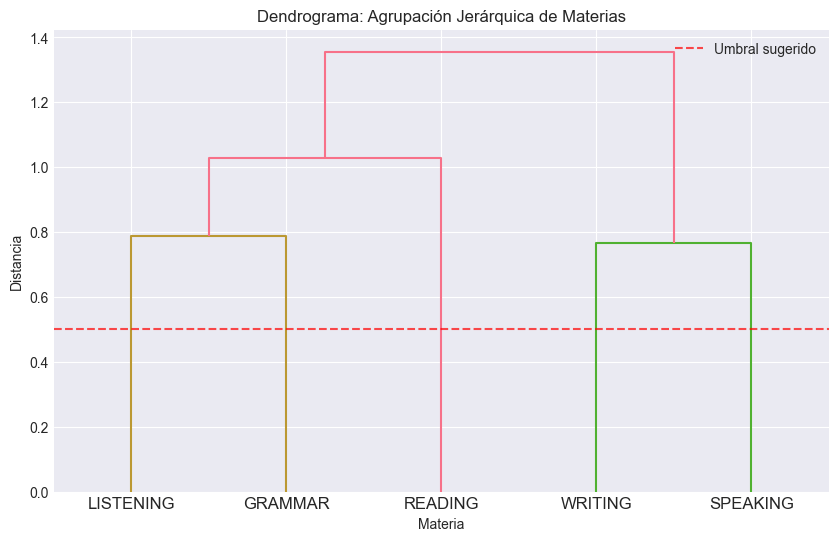


Asignación de clusters (umbral = 0.5):
  Cluster 1: SPEAKING
  Cluster 2: WRITING
  Cluster 3: GRAMMAR
  Cluster 4: LISTENING
  Cluster 5: READING

b) Análisis de Componentes Principales (PCA):
Varianza explicada por cada componente:
  PC1: 0.453 (45.3%)
  PC2: 0.195 (19.5%)
  PC3: 0.147 (14.7%)
  PC4: 0.108 (10.8%)
  PC5: 0.097 (9.7%)

Varianza acumulada:
  PC1 a PC1: 0.453 (45.3%)
  PC1 a PC2: 0.648 (64.8%)
  PC1 a PC3: 0.796 (79.6%)
  PC1 a PC4: 0.903 (90.3%)
  PC1 a PC5: 1.000 (100.0%)

Matriz de cargas (loadings):
             PC1    PC2    PC3    PC4    PC5
GRAMMAR    0.776 -0.275 -0.104 -0.106  0.549
SPEAKING   0.680  0.495 -0.023  0.541  0.009
LISTENING  0.623 -0.545 -0.422  0.082 -0.362
WRITING    0.650  0.553 -0.147 -0.474 -0.159
READING    0.628 -0.228  0.725 -0.046 -0.164


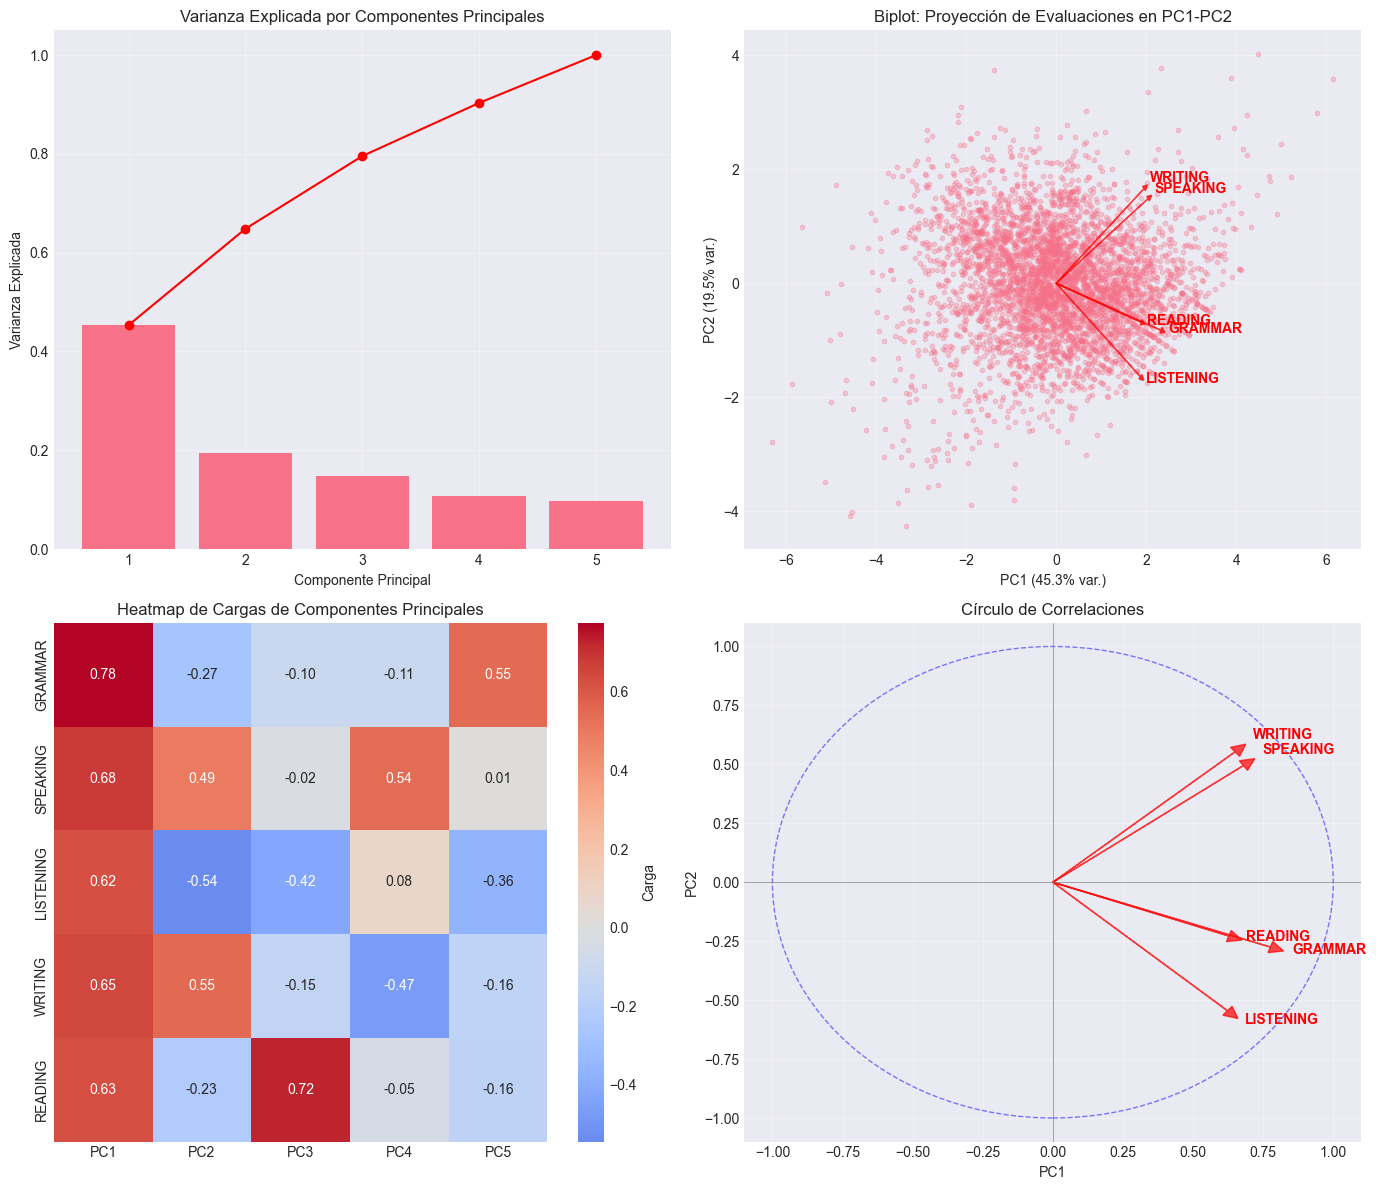


Interpretación de Componentes Principales:

PC1 (explica 45.3% de varianza):
  Materias con mayor influencia (carga absoluta):
    GRAMMAR: +0.776
    SPEAKING: +0.680
    WRITING: +0.650

PC2 (explica 19.5% de varianza):
  Materias con mayor influencia (carga absoluta):
    WRITING: +0.553
    LISTENING: -0.545
    SPEAKING: +0.495

3. ANÁLISIS DE COMBINACIONES DE MATERIAS

a) Análisis de Combinaciones por Pares:

Pares de materias más correlacionados:
  GRAMMAR - LISTENING: r = 0.469
  SPEAKING - WRITING: r = 0.461
  GRAMMAR - READING: r = 0.389
  GRAMMAR - SPEAKING: r = 0.341
  GRAMMAR - WRITING: r = 0.330

b) Análisis de Combinaciones de Tríos:

Tríos de materias con mayor consistencia interna (Alpha de Cronbach):
  GRAMMAR + LISTENING + READING:
    Alpha = 0.640, Corr. promedio = 0.374
  GRAMMAR + LISTENING + WRITING:
    Alpha = 0.585, Corr. promedio = 0.328
  GRAMMAR + SPEAKING + LISTENING:
    Alpha = 0.571, Corr. promedio = 0.338
  GRAMMAR + WRITING + READING:
    Alpha = 0.

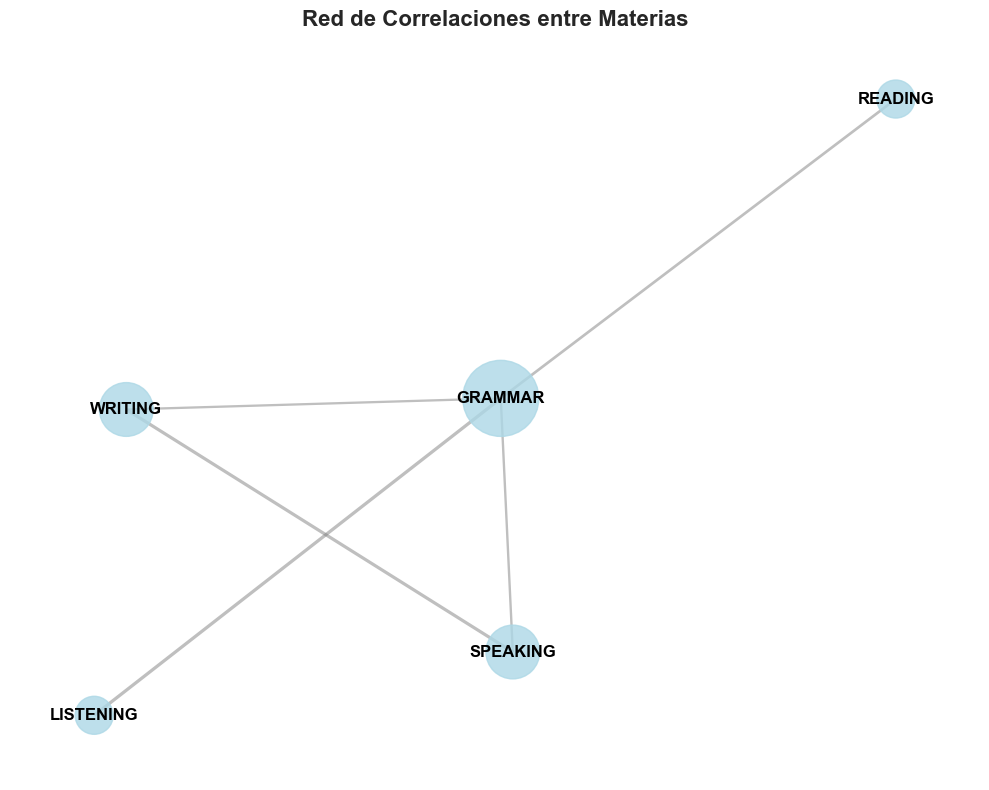


4. ANÁLISIS DE PATRONES DE RENDIMIENTO

a) Clustering de Estudiantes por Patrón de Rendimiento:


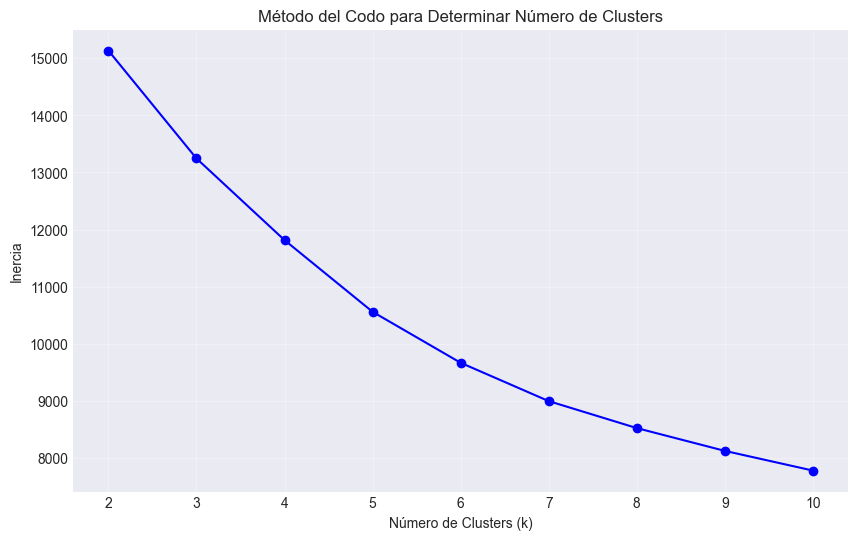

Número de clusters seleccionado: 3

Perfiles de rendimiento por cluster (promedio de materias):

Cluster 0 (n=2058):

Cluster 1 (n=1171):
  Materias fuertes: GRAMMAR, SPEAKING, LISTENING, WRITING, READING

Cluster 2 (n=962):
  Materias débiles: GRAMMAR, SPEAKING, LISTENING, WRITING, READING


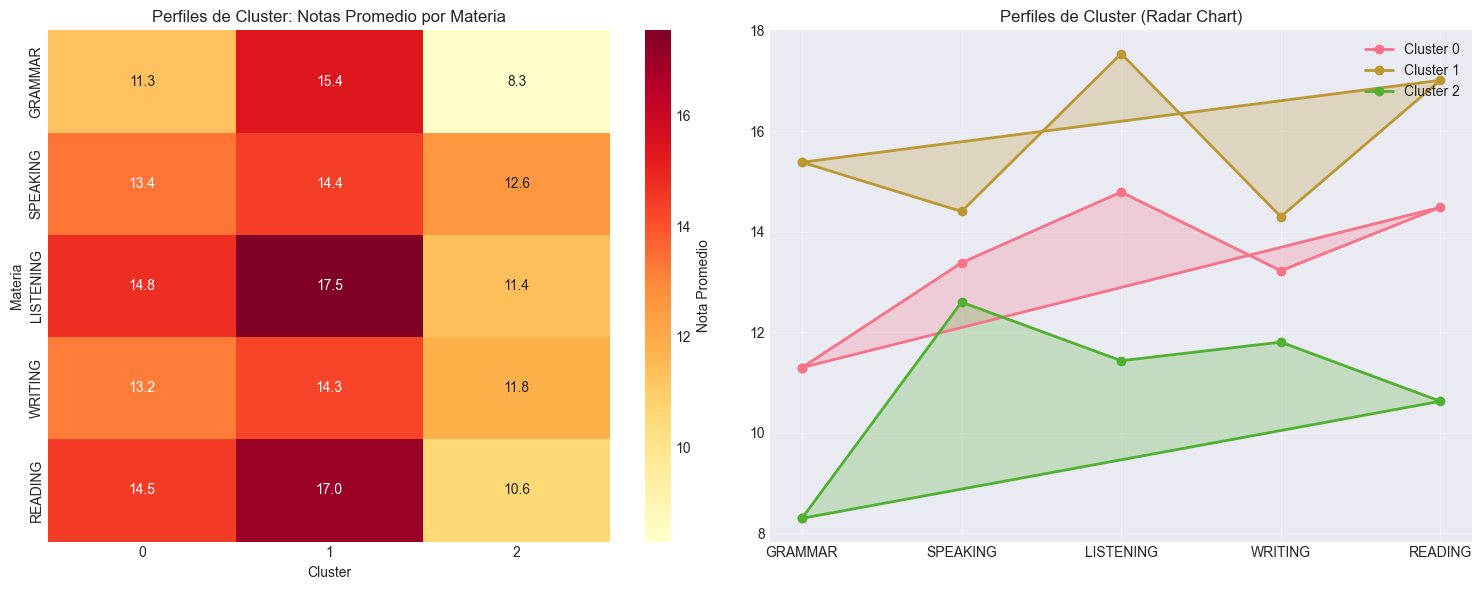


b) Análisis de Patrones de Rendimiento Extremo:
Estudiantes con alto rendimiento en TODAS las materias: 89
Estudiantes con bajo rendimiento en TODAS las materias: 67

Combinaciones más comunes de materias con alto rendimiento:

Top 5 combinaciones de materias con alto rendimiento concurrente:
  GRAMMAR, LISTENING: 174 estudiantes (4.2%)
  SPEAKING, WRITING: 142 estudiantes (3.4%)
  GRAMMAR, LISTENING, READING, SPEAKING, WRITING: 89 estudiantes (2.1%)
  GRAMMAR, LISTENING, READING: 89 estudiantes (2.1%)
  GRAMMAR, READING: 86 estudiantes (2.1%)

5. ANÁLISIS DE SINERGIAS Y COMPLEMENTARIEDAD

a) Influencia de otras materias en cada materia individual:

Materias mejor explicadas por otras materias:
  GRAMMAR: R² = 0.351
    Más influenciada por: LISTENING (beta = 0.354)
  SPEAKING: R² = 0.265
    Más influenciada por: WRITING (beta = 0.377)
  WRITING: R² = 0.248
    Más influenciada por: SPEAKING (beta = 0.386)
  LISTENING: R² = 0.230
    Más influenciada por: GRAMMAR (beta = 0.420)
  REA

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from itertools import combinations

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Leer los datos
print("=== CARGANDO Y PREPARANDO DATOS ===")
df = pd.read_excel('C:\\LLUIS\\Dropbox\\IT ACADEMY\\Sprint13\\df_principal_modificat.xlsx')

# Convertir columnas numéricas
numeric_columns = ['RESULT', 'PUNTS', 'MAXPUNTS', 'TOTAL', 'EDAD']
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

# Crear dataset a nivel de evaluación con las 5 materias como columnas
df_pivot = df.pivot_table(
    index=['IDEVALUACIO', 'IDALUMNE', 'EDAD', 'SEXO', 'TIPUS_ESCOLA', 'PROFE'],
    columns='MATERIA',
    values='RESULT',
    aggfunc='mean'
).reset_index()

# Lista de materias
materias = ['GRAMMAR', 'SPEAKING', 'LISTENING', 'WRITING', 'READING']
materias_disponibles = [m for m in materias if m in df_pivot.columns]

print(f"Materias disponibles para análisis: {materias_disponibles}")
print(f"Evaluaciones completas: {df_pivot.dropna(subset=materias_disponibles).shape[0]}")

# Dataset limpio
df_clean = df_pivot.dropna(subset=materias_disponibles)
df_materias = df_clean[materias_disponibles].copy()

print(f"\nDataset final para análisis de combinaciones: {df_materias.shape}")

# 1. ANÁLISIS DE CORRELACIÓN ENTRE MATERIAS
print("\n" + "="*60)
print("1. ANÁLISIS DE CORRELACIÓN ENTRE MATERIAS")
print("="*60)

# Matriz de correlación
correlation_matrix = df_materias.corr()

print("\nMatriz de correlación (Pearson):")
print(correlation_matrix.round(3))

# Calcular correlaciones estadísticamente significativas
print("\nCorrelaciones significativas (p < 0.05):")
n = len(df_materias)
for i, materia1 in enumerate(materias_disponibles):
    for j, materia2 in enumerate(materias_disponibles):
        if i < j:  # Solo la mitad de la matriz
            corr, p_value = pearsonr(df_materias[materia1], df_materias[materia2])
            if p_value < 0.05:
                print(f"  {materia1} - {materia2}: r = {corr:.3f}, p = {p_value:.4f}")

# Visualización de la matriz de correlación
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, cbar_kws={'label': 'Coeficiente de Correlación'})
plt.title('Correlación entre Materias', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. ANÁLISIS DE GRUPOS DE MATERIAS CORRELACIONADAS
print("\n" + "="*60)
print("2. ANÁLISIS DE GRUPOS Y COMBINACIONES")
print("="*60)

# a) Análisis de clúster jerárquico de materias
print("\na) Análisis de Clúster Jerárquico de Materias:")

# Calcular la matriz de distancias (1 - correlación absoluta)
distance_matrix = 1 - np.abs(correlation_matrix.values)

# Enlace jerárquico
linkage_matrix = linkage(distance_matrix, method='ward')

# Dendrograma
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=materias_disponibles, 
           orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrograma: Agrupación Jerárquica de Materias')
plt.xlabel('Materia')
plt.ylabel('Distancia')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Umbral sugerido')
plt.legend()
plt.show()

# Formar clusters a un umbral de distancia
threshold = 0.5
clusters = fcluster(linkage_matrix, threshold, criterion='distance')
cluster_assignments = dict(zip(materias_disponibles, clusters))

print("\nAsignación de clusters (umbral = 0.5):")
for cluster_num in sorted(set(clusters)):
    materias_cluster = [materia for materia, c in cluster_assignments.items() if c == cluster_num]
    print(f"  Cluster {cluster_num}: {', '.join(materias_cluster)}")

# b) Análisis de Componentes Principales (PCA)
print("\nb) Análisis de Componentes Principales (PCA):")

# Estandarizar datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_materias)

# Aplicar PCA
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

print(f"Varianza explicada por cada componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f} ({var*100:.1f}%)")

print(f"\nVarianza acumulada:")
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
for i, var in enumerate(cumulative_var):
    print(f"  PC1 a PC{i+1}: {var:.3f} ({var*100:.1f}%)")

# Matriz de carga (correlación entre materias y componentes)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, 
                          index=materias_disponibles, 
                          columns=[f'PC{i+1}' for i in range(len(materias_disponibles))])

print("\nMatriz de cargas (loadings):")
print(loadings_df.round(3))

# Visualización de PCA
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Varianza explicada
axes[0, 0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
axes[0, 0].plot(range(1, len(cumulative_var)+1), cumulative_var, 'ro-')
axes[0, 0].set_xlabel('Componente Principal')
axes[0, 0].set_ylabel('Varianza Explicada')
axes[0, 0].set_title('Varianza Explicada por Componentes Principales')
axes[0, 0].grid(True, alpha=0.3)

# 2. Biplot (PC1 vs PC2)
pc1_loadings = loadings_df['PC1']
pc2_loadings = loadings_df['PC2']

axes[0, 1].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3, s=10)
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
axes[0, 1].set_title('Biplot: Proyección de Evaluaciones en PC1-PC2')
axes[0, 1].grid(True, alpha=0.3)

# Añadir vectores de materias
for i, materia in enumerate(materias_disponibles):
    axes[0, 1].arrow(0, 0, pc1_loadings[i]*3, pc2_loadings[i]*3, 
                     head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)
    axes[0, 1].text(pc1_loadings[i]*3.2, pc2_loadings[i]*3.2, 
                    materia, color='red', fontsize=10, fontweight='bold')

# 3. Heatmap de cargas
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[1, 0], cbar_kws={'label': 'Carga'})
axes[1, 0].set_title('Heatmap de Cargas de Componentes Principales')

# 4. Círculo de correlaciones
# Crear círculo
circle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--', alpha=0.5)
axes[1, 1].add_artist(circle)

# Añadir vectores normalizados
for i, materia in enumerate(materias_disponibles):
    x = pc1_loadings[i]
    y = pc2_loadings[i]
    axes[1, 1].arrow(0, 0, x, y, head_width=0.05, head_length=0.05, 
                     fc='red', ec='red', alpha=0.7)
    axes[1, 1].text(x*1.1, y*1.1, materia, color='red', fontsize=10, fontweight='bold')

axes[1, 1].set_xlim(-1.1, 1.1)
axes[1, 1].set_ylim(-1.1, 1.1)
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')
axes[1, 1].set_title('Círculo de Correlaciones')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='grey', linestyle='-', linewidth=0.5)
axes[1, 1].axvline(x=0, color='grey', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Interpretación de componentes principales
print("\nInterpretación de Componentes Principales:")
for i in range(min(2, len(materias_disponibles))):  # Analizar los primeros 2 PCs
    pc_num = i + 1
    print(f"\nPC{pc_num} (explica {pca.explained_variance_ratio_[i]*100:.1f}% de varianza):")
    
    # Ordenar cargas absolutas
    sorted_loadings = loadings_df[f'PC{pc_num}'].abs().sort_values(ascending=False)
    
    print(f"  Materias con mayor influencia (carga absoluta):")
    for materia, loading in sorted_loadings.head(3).items():
        sign = "+" if loadings_df.loc[materia, f'PC{pc_num}'] > 0 else "-"
        print(f"    {materia}: {sign}{loading:.3f}")

# 3. ANÁLISIS DE COMBINACIONES DE MATERIAS
print("\n" + "="*60)
print("3. ANÁLISIS DE COMBINACIONES DE MATERIAS")
print("="*60)

# a) Análisis de todas las combinaciones posibles (pares)
print("\na) Análisis de Combinaciones por Pares:")

# Calcular correlación para cada par
pairwise_correlations = []
for i, materia1 in enumerate(materias_disponibles):
    for j, materia2 in enumerate(materias_disponibles):
        if i < j:
            corr = correlation_matrix.loc[materia1, materia2]
            pairwise_correlations.append({
                'Materia1': materia1,
                'Materia2': materia2,
                'Correlación': corr,
                '|Correlación|': abs(corr)
            })

pairwise_df = pd.DataFrame(pairwise_correlations)
pairwise_df = pairwise_df.sort_values('|Correlación|', ascending=False)

print("\nPares de materias más correlacionados:")
for idx, row in pairwise_df.head(5).iterrows():
    print(f"  {row['Materia1']} - {row['Materia2']}: r = {row['Correlación']:.3f}")

# b) Análisis de tríos de materias
print("\nb) Análisis de Combinaciones de Tríos:")

# Calcular consistencia interna (alpha de Cronbach) para cada trío
def cronbach_alpha(items_df):
    """Calcula el alpha de Cronbach para un conjunto de ítems."""
    items = items_df.values
    k = items.shape[1]
    
    if k < 2:
        return np.nan
    
    # Varianza de cada ítem
    item_variances = np.var(items, axis=0, ddof=1)
    
    # Varianza de la suma total
    total_scores = np.sum(items, axis=1)
    total_variance = np.var(total_scores, ddof=1)
    
    # Alpha de Cronbach
    alpha = (k / (k - 1)) * (1 - np.sum(item_variances) / total_variance)
    
    return alpha

# Generar todos los tríos posibles
trio_results = []
for trio in combinations(materias_disponibles, 3):
    trio_df = df_materias[list(trio)]
    alpha = cronbach_alpha(trio_df)
    mean_corr = trio_df.corr().values[np.triu_indices(3, k=1)].mean()
    
    trio_results.append({
        'Trio': trio,
        'Alpha_Cronbach': alpha,
        'Correlación_Promedio': mean_corr,
        'Materias': ' + '.join(trio)
    })

trio_df = pd.DataFrame(trio_results)
trio_df = trio_df.sort_values('Alpha_Cronbach', ascending=False)

print("\nTríos de materias con mayor consistencia interna (Alpha de Cronbach):")
for idx, row in trio_df.head(5).iterrows():
    print(f"  {row['Materias']}:")
    print(f"    Alpha = {row['Alpha_Cronbach']:.3f}, Corr. promedio = {row['Correlación_Promedio']:.3f}")

# c) Análisis de redes de correlación
print("\nc) Análisis de Redes de Correlación:")

# Crear grafo de correlaciones
G = nx.Graph()

# Añadir nodos (materias)
for materia in materias_disponibles:
    G.add_node(materia)

# Añadir aristas (solo correlaciones significativas y positivas)
for i, materia1 in enumerate(materias_disponibles):
    for j, materia2 in enumerate(materias_disponibles):
        if i < j:
            corr = correlation_matrix.loc[materia1, materia2]
            if corr > 0.3:  # Umbral de correlación
                G.add_edge(materia1, materia2, weight=corr)

# Calcular métricas de la red
print("\nMétricas de la red de correlaciones:")
print(f"  Número de nodos: {G.number_of_nodes()}")
print(f"  Número de aristas: {G.number_of_edges()}")

if G.number_of_edges() > 0:
    # Centralidad de grado
    degree_centrality = nx.degree_centrality(G)
    print("\n  Centralidad de grado (materias más conectadas):")
    for materia, centrality in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True):
        print(f"    {materia}: {centrality:.3f}")
    
    # Clustering coefficient
    clustering_coeff = nx.clustering(G)
    print("\n  Coeficiente de clustering (agrupación local):")
    for materia, coeff in sorted(clustering_coeff.items(), key=lambda x: x[1], reverse=True):
        print(f"    {materia}: {coeff:.3f}")

# Visualización de la red
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

# Dibujar nodos
node_sizes = [degree_centrality.get(node, 0.1) * 3000 for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                       node_color='lightblue', alpha=0.8)

# Dibujar aristas
edge_weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_weights, 
                       alpha=0.5, edge_color='gray')

# Dibujar etiquetas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

plt.title('Red de Correlaciones entre Materias', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# 4. ANÁLISIS DE CLÚSTERES DE ESTUDIANTES BASADO EN PATRONES DE MATERIAS
print("\n" + "="*60)
print("4. ANÁLISIS DE PATRONES DE RENDIMIENTO")
print("="*60)

# a) Clustering de estudiantes basado en sus perfiles de materias
print("\na) Clustering de Estudiantes por Patrón de Rendimiento:")

# Estandarizar datos
scaler_students = StandardScaler()
df_students_scaled = scaler_students.fit_transform(df_materias)

# Determinar número óptimo de clusters usando método del codo
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(df_students_scaled)
    inertias.append(kmeans.inertia_)

# Método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Determinar Número de Clusters')
plt.grid(True, alpha=0.3)
plt.show()

# Seleccionar k (basado en el codo)
optimal_k = 3  # Se puede ajustar visualmente
print(f"Número de clusters seleccionado: {optimal_k}")

# Aplicar K-means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(df_students_scaled)

# Añadir clusters al dataframe
df_with_clusters = df_materias.copy()
df_with_clusters['Cluster'] = cluster_labels

# Analizar perfiles por cluster
print("\nPerfiles de rendimiento por cluster (promedio de materias):")
cluster_profiles = df_with_clusters.groupby('Cluster')[materias_disponibles].mean()

for cluster in range(optimal_k):
    print(f"\nCluster {cluster} (n={sum(cluster_labels == cluster)}):")
    cluster_data = cluster_profiles.loc[cluster]
    
    # Materias fuertes (por encima del promedio general)
    overall_mean = df_materias.mean()
    strong_materias = []
    weak_materias = []
    
    for materia in materias_disponibles:
        if cluster_data[materia] > overall_mean[materia] + 0.5:
            strong_materias.append(materia)
        elif cluster_data[materia] < overall_mean[materia] - 0.5:
            weak_materias.append(materia)
    
    if strong_materias:
        print(f"  Materias fuertes: {', '.join(strong_materias)}")
    if weak_materias:
        print(f"  Materias débiles: {', '.join(weak_materias)}")

# Visualización de perfiles de cluster
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Heatmap de perfiles
sns.heatmap(cluster_profiles.T, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': 'Nota Promedio'})
axes[0].set_title('Perfiles de Cluster: Notas Promedio por Materia')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Materia')

# 2. Gráfico de radar por cluster
# Preparar datos para radar chart
angles = np.linspace(0, 2*np.pi, len(materias_disponibles), endpoint=False).tolist()
angles += angles[:1]  # Cerrar el círculo

for cluster in range(optimal_k):
    values = cluster_profiles.loc[cluster, materias_disponibles].values.tolist()
    values += values[:1]  # Cerrar el círculo
    
    axes[1].plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}')
    axes[1].fill(angles, values, alpha=0.25)

axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(materias_disponibles, fontsize=10)
axes[1].set_title('Perfiles de Cluster (Radar Chart)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# b) Análisis de patrones de rendimiento extremo
print("\nb) Análisis de Patrones de Rendimiento Extremo:")

# Definir percentiles para alto y bajo rendimiento
threshold_high = df_materias.quantile(0.75) # percentil 75
threshold_low = df_materias.quantile(0.25)  # percentil 25

# Contar patrones de "alto en todas las materias"
high_in_all = ((df_materias > threshold_high).all(axis=1)).sum()
low_in_all = ((df_materias < threshold_low).all(axis=1)).sum()

print(f"Estudiantes con alto rendimiento en TODAS las materias: {high_in_all}")
print(f"Estudiantes con bajo rendimiento en TODAS las materias: {low_in_all}")

# Analizar combinaciones más comunes de materias altas
print("\nCombinaciones más comunes de materias con alto rendimiento:")
high_counts = {}
for idx, row in df_materias.iterrows():
    high_materias = [materia for materia in materias_disponibles 
                     if row[materia] > threshold_high[materia]]
    if len(high_materias) >= 2:
        # Ordenar y crear tupla para contar
        combo = tuple(sorted(high_materias))
        high_counts[combo] = high_counts.get(combo, 0) + 1

# Ordenar combinaciones más comunes
sorted_combos = sorted(high_counts.items(), key=lambda x: x[1], reverse=True)

print("\nTop 5 combinaciones de materias con alto rendimiento concurrente:")
for combo, count in sorted_combos[:5]:
    combo_percentage = (count / len(df_materias)) * 100
    print(f"  {', '.join(combo)}: {count} estudiantes ({combo_percentage:.1f}%)")

# 5. ANÁLISIS DE SINERGIAS ENTRE MATERIAS
print("\n" + "="*60)
print("5. ANÁLISIS DE SINERGIAS Y COMPLEMENTARIEDAD")
print("="*60)

# a) Análisis de regresión múltiple para cada materia
print("\na) Influencia de otras materias en cada materia individual:")

synergy_results = []
for target_materia in materias_disponibles:
    # Variables predictoras: todas las demás materias
    predictor_materias = [m for m in materias_disponibles if m != target_materia]
    
    if len(predictor_materias) > 0:
        X = df_materias[predictor_materias]
        y = df_materias[target_materia]
        
        # Modelo de regresión lineal
        from sklearn.linear_model import LinearRegression
        from sklearn.metrics import r2_score
        
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        
        # Coeficientes estandarizados
        scaler_synergy = StandardScaler()
        X_scaled = scaler_synergy.fit_transform(X)
        y_scaled = (y - y.mean()) / y.std()
        
        model_scaled = LinearRegression()
        model_scaled.fit(X_scaled, y_scaled)
        
        # Encontrar la materia que más influye
        max_influence_idx = np.argmax(np.abs(model_scaled.coef_))
        max_influence_materia = predictor_materias[max_influence_idx]
        max_influence_value = model_scaled.coef_[max_influence_idx]
        
        synergy_results.append({
            'Materia_Objetivo': target_materia,
            'R2': r2,
            'Materia_Mas_Influyente': max_influence_materia,
            'Influencia': max_influence_value,
            'Prediccion': f"La materia {target_materia} está más influenciada por {max_influence_materia}"
        })

synergy_df = pd.DataFrame(synergy_results)
synergy_df = synergy_df.sort_values('R2', ascending=False)

print("\nMaterias mejor explicadas por otras materias:")
for idx, row in synergy_df.iterrows():
    print(f"  {row['Materia_Objetivo']}: R² = {row['R2']:.3f}")
    print(f"    Más influenciada por: {row['Materia_Mas_Influyente']} (beta = {row['Influencia']:.3f})")

# b) Análisis de complementariedad
print("\nb) Análisis de Complementariedad (materias que se compensan):")

# Buscar pares con correlación negativa o baja
low_correlation_pairs = []
for i, materia1 in enumerate(materias_disponibles):
    for j, materia2 in enumerate(materias_disponibles):
        if i < j:
            corr = correlation_matrix.loc[materia1, materia2]
            if corr < 0.1:  # Baja correlación
                low_correlation_pairs.append({
                    'Materia1': materia1,
                    'Materia2': materia2,
                    'Correlación': corr
                })

if low_correlation_pairs:
    print("\nPares de materias con baja correlación (posible complementariedad):")
    low_corr_df = pd.DataFrame(low_correlation_pairs)
    low_corr_df = low_corr_df.sort_values('Correlación')
    
    for idx, row in low_corr_df.head(5).iterrows():
        print(f"  {row['Materia1']} - {row['Materia2']}: r = {row['Correlación']:.3f}")
        
        # Verificar si los estudiantes tienden a tener una alta y otra baja
        diff = df_materias[row['Materia1']] - df_materias[row['Materia2']]
        extreme_diff = (abs(diff) > diff.std() * 1.5).sum()
        diff_percentage = (extreme_diff / len(df_materias)) * 100
        
        print(f"    {diff_percentage:.1f}% de estudiantes tienen diferencia extrema entre estas materias")
else:
    print("No se encontraron pares con baja correlación significativa.")

# 6. CONCLUSIONES Y RECOMENDACIONES
print("\n" + "="*60)
print("CONCLUSIONES: COMBINACIONES CLAVE DE MATERIAS")
print("="*60)

# Resumen de hallazgos principales
print("\nHALLazGOS PRINCIPALES:")

# 1. Materias más correlacionadas
top_pair = pairwise_df.iloc[0]
print(f"\n1. Las materias más correlacionadas son:")
print(f"   {top_pair['Materia1']} y {top_pair['Materia2']} (r = {top_pair['Correlación']:.3f})")
print(f"   Esto sugiere que el dominio en una predice bien el dominio en la otra")

# 2. Tríos más consistentes
top_trio = trio_df.iloc[0]
print(f"\n2. El trío de materias más consistente es:")
print(f"   {top_trio['Materias']}")
print(f"   Alpha de Cronbach = {top_trio['Alpha_Cronbach']:.3f}")
print(f"   Estas materias miden habilidades relacionadas o complementarias")

# 3. Componentes principales
print(f"\n3. Análisis de Componentes Principales:")
print(f"   PC1 explica el {pca.explained_variance_ratio_[0]*100:.1f}% de la varianza")
pc1_materias = loadings_df['PC1'].abs().nlargest(2).index.tolist()
print(f"   Las materias que más contribuyen a PC1 son: {pc1_materias[0]} y {pc1_materias[1]}")

# 4. Patrones de cluster
print(f"\n4. Patrones de rendimiento identificados:")
for cluster in range(optimal_k):
    cluster_size = sum(cluster_labels == cluster)
    percentage = (cluster_size / len(cluster_labels)) * 100
    print(f"   Cluster {cluster}: {cluster_size} estudiantes ({percentage:.1f}%)")

# 5. Sinergias clave
top_synergy = synergy_df.iloc[0]
print(f"\n5. Mayor sinergia encontrada:")
print(f"   La materia {top_synergy['Materia_Objetivo']} está fuertemente influenciada por")
print(f"   {top_synergy['Materia_Mas_Influyente']} (R² = {top_synergy['R2']:.3f})")

print("\n" + "="*60)
print("RECOMENDACIONES PRÁCTICAS")
print("="*60)

print("""
1. ENSEÑANZA INTEGRADA:
   • Enfocar la enseñanza de {materia1} y {materia2} de manera integrada
   • Diseñar actividades que combinen estas habilidades

2. EVALUACIÓN:
   • Considerar la evaluación conjunta de materias altamente correlacionadas
   • Desarrollar pruebas que capturen habilidades transversales

3. INTERVENCIONES:
   • Para estudiantes con bajo rendimiento en un cluster específico,
     diseñar intervenciones focalizadas en las materias débiles de ese patrón

4. TUTORÍAS:
   • Agrupar estudiantes por patrones de rendimiento para tutorías especializadas
   • Desarrollar materiales complementarios para materias con baja correlación
   
5. PLANIFICACIÓN CURRICULAR:
   • Secuenciar la enseñanza de materias relacionadas de manera consecutiva
   • Crear proyectos interdisciplinarios que integren materias complementarias
""".format(
    materia1=top_pair['Materia1'],
    materia2=top_pair['Materia2']
))

# Guardar resultados
print("\n=== GUARDANDO RESULTADOS ===")

# Guardar datos con clusters
df_with_clusters.to_csv('combinaciones_materias_con_clusters.csv', index=False)

# Guardar análisis de combinaciones
summary_data = {
    'Top_Pair': [f"{top_pair['Materia1']} - {top_pair['Materia2']}"],
    'Correlacion_Top_Pair': [top_pair['Correlación']],
    'Top_Trio': [top_trio['Materias']],
    'Alpha_Top_Trio': [top_trio['Alpha_Cronbach']],
    'PC1_Varianza': [pca.explained_variance_ratio_[0]],
    'PC1_Materias_Principales': [f"{pc1_materias[0]}, {pc1_materias[1]}"],
    'Materia_Mas_Central': [max(degree_centrality, key=degree_centrality.get) if degree_centrality else "N/A"]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('resumen_combinaciones_clave.csv', index=False)

print("Archivos guardados:")
print("  1. combinaciones_materias_con_clusters.csv - Datos con asignación de clusters")
print("  2. resumen_combinaciones_clave.csv - Resumen de combinaciones más importantes")

print("\n" + "="*60)
print("¡ANÁLISIS DE COMBINACIONES COMPLETADO!")
print("="*60)